# Import Libraries

In [1]:
import nltk; nltk.download('stopwords')

import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from time import sleep
import joblib
from tqdm import tqdm
tqdm.pandas()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
import nltk
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('brown')
nltk.download('punkt')
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
from string import punctuation
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

# Lemmatize with POS Tag
from nltk.corpus import wordnet

# Read dataset

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
import json
from sklearn.model_selection import train_test_split

REVIEWS_LIMIT = None

def load_rows(filepath, nrows = None, func = None):
    with open(filepath) as json_file:
        count = 0
        objs = []
        line = json_file.readline()
        while (nrows is None or count < nrows) and line:
            count += 1
            obj = json.loads(line)
            if func != None :
                func(obj)
            objs.append(obj)
            line = json_file.readline()
        return pd.DataFrame(objs)
    
def add_sentiment(obj) :
  # if stars < 4 = Negative
    if (obj["stars"] < 4):
        obj["label"] = 0
    else:
        obj["label"] = 1

# replace with the file location
reviews = load_rows('./gdrive/My Drive/BT4222/yelp_academic_dataset_review.json', REVIEWS_LIMIT, add_sentiment)
business = load_rows('./gdrive/My Drive/BT4222/yelp_academic_dataset_business.json', REVIEWS_LIMIT, add_sentiment)

print('Review objects loaded. Count = {}'.format(reviews.shape[0]))

reviews['text_length'] = reviews['text'].apply(lambda x:len(x.split()))

# 80% train, 20% test
reviews_train, reviews_test = train_test_split(reviews, test_size = 0.2)


Review objects loaded. Count = 1125458


## EDA

In [6]:
pd.DataFrame(business).dtypes

business_id       object
full_address      object
hours             object
open                bool
categories        object
city              object
review_count       int64
name              object
neighborhoods     object
longitude        float64
state             object
stars            float64
latitude         float64
attributes        object
type              object
label              int64
dtype: object

In [7]:
lst = []
for i in business["categories"]:
  for x in i:
    if x not in lst:
      lst.append(x)
print(lst)
len(lst)

['Doctors', 'Health & Medical', 'Restaurants', 'American (Traditional)', 'Food', 'Ice Cream & Frozen Yogurt', 'Fast Food', 'Chinese', 'Television Stations', 'Mass Media', 'Home Services', 'Heating & Air Conditioning/HVAC', 'Libraries', 'Public Services & Government', 'Veterinarians', 'Pets', 'Bars', 'Nightlife', 'Lounges', 'Hotels & Travel', 'Bed & Breakfast', 'Event Planning & Services', 'Hotels', 'Active Life', 'Bowling', 'Pizza', 'Party & Event Planning', 'Caterers', 'Asian Fusion', 'Venues & Event Spaces', 'Mexican', 'Auto Repair', 'Automotive', 'Auto Parts & Supplies', 'Car Dealers', 'Arts & Entertainment', 'Stadiums & Arenas', 'Pet Services', 'Pilates', 'Yoga', 'Weight Loss Centers', 'Fitness & Instruction', 'Sandwiches', 'Chicken Wings', 'Shopping', 'Arts & Crafts', 'Cards & Stationery', 'Art Supplies', 'Flowers & Gifts', 'Knitting Supplies', 'Hobby Shops', "Women's Clothing", 'Shopping Centers', 'Fashion', 'Beer, Wine & Spirits', 'Coffee & Tea', 'Bakeries', 'Breakfast & Brunch'

715

In [8]:
reviews

,votes,user_id,review_id,stars,date,text,type,business_id,label,text_length
0,"{'funny': 0, 'useful': 2, 'cool': 1}",Xqd0DzHaiyRqVH3WRG7hzg,15SdjuK7DmYqUAj6rjGowg,5,2007-05-17,dr. goldberg offers everything i look for in a...,review,vcNAWiLM4dR7D2nwwJ7nCA,1,93
1,"{'funny': 0, 'useful': 2, 'cool': 0}",H1kH6QZV7Le4zqTRNxoZow,RF6UnRTtG7tWMcrO2GEoAg,2,2010-03-22,"Unfortunately, the frustration of being Dr. Go...",review,vcNAWiLM4dR7D2nwwJ7nCA,0,115
2,"{'funny': 0, 'useful': 1, 'cool': 1}",zvJCcrpm2yOZrxKffwGQLA,-TsVN230RCkLYKBeLsuz7A,4,2012-02-14,Dr. Goldberg has been my doctor for years and ...,review,vcNAWiLM4dR7D2nwwJ7nCA,1,55
3,"{'funny': 0, 'useful': 0, 'cool': 0}",KBLW4wJA_fwoWmMhiHRVOA,dNocEAyUucjT371NNND41Q,4,2012-03-02,Been going to Dr. Goldberg for over 10 years. ...,review,vcNAWiLM4dR7D2nwwJ7nCA,1,97
4,"{'funny': 0, 'useful': 2, 'cool': 1}",zvJCcrpm2yOZrxKffwGQLA,ebcN2aqmNUuYNoyvQErgnA,4,2012-05-15,Got a letter in the mail last week that said D...,review,vcNAWiLM4dR7D2nwwJ7nCA,1,53
...,...,...,...,...,...,...,...,...,...,...
1125453,"{'funny': 0, 'useful': 1, 'cool': 0}",lhMo-dGq0V2iKqBIiwUJSg,eujuvkGqy2ssZ9zjdPJrMA,5,2010-08-11,"Located at the bottom of Lauriston Place, this...",review,BVxlrYWgmi-8TPGMe6CTpg,1,122
1125454,"{'funny': 2, 'useful': 1, 'cool': 1}",TTrzXCtB2MZA8Azw56bRlw,vFA5KXUGEH-oMcM6WTC-8w,5,2012-06-15,I love this place! I think the staff struggle ...,review,BVxlrYWgmi-8TPGMe6CTpg,1,136
1125455,"{'funny': 0, 'useful': 2, 'cool': 1}",rtS7mDof5d-cEPBsmVuUJw,0sVK4VUxvj3cy78W0DlvWQ,3,2013-09-17,Perfect little shop to go to if you want to pi...,review,BVxlrYWgmi-8TPGMe6CTpg,0,191
1125456,"{'funny': 1, 'useful': 1, 'cool': 1}",tZs84cKAUSOtP_nAiSdreQ,Nx88b_tCsP7Oja3PvhR5tQ,4,2013-09-18,I visit here once or twice a month. Just to ge...,review,BVxlrYWgmi-8TPGMe6CTpg,1,111


## Filter dataset that contain 'Restaurant' as the category

In [9]:
col = [x for x in business]
res = []
df = pd.DataFrame(columns = col)
for x in business.iterrows():
  if "Restaurants" in x[1][4]:
    res.append(x[1])

# filtered dataframe where "Restaurants" is in the categories
df = pd.DataFrame(res, columns = col)
df

,business_id,full_address,hours,open,categories,city,review_count,name,neighborhoods,longitude,state,stars,latitude,attributes,type,label
1,JwUE5GmEO-sH1FuwJgKBlQ,"6162 US Highway 51\nDe Forest, WI 53532",{},True,[Restaurants],De Forest,26,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1
2,uGykseHzyS5xAMWoN6YUqA,"505 W North St\nDe Forest, WI 53532","{'Monday': {'close': '22:00', 'open': '06:00'}...",True,"[American (Traditional), Restaurants]",De Forest,16,Deforest Family Restaurant,[],-89.353437,WI,4.0,43.252267,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1
3,LRKJF43s9-3jG9Lgx4zODg,"4910 County Rd V\nDe Forest, WI 53532","{'Monday': {'close': '22:00', 'open': '10:30'}...",True,"[Food, Ice Cream & Frozen Yogurt, Fast Food, R...",De Forest,7,Culver's,[],-89.374983,WI,4.5,43.251045,"{'Take-out': True, 'Wi-Fi': 'free', 'Takes Res...",business,1
4,RgDg-k9S5YD_BaxMckifkg,"631 S Main St\nDe Forest, WI 53532","{'Monday': {'close': '22:00', 'open': '11:00'}...",True,"[Chinese, Restaurants]",De Forest,3,Chang Jiang Chinese Kitchen,[],-89.343722,WI,4.0,43.240875,"{'Take-out': True, 'Has TV': False, 'Outdoor S...",business,1
8,rdAdANPNOcvUtoFgcaY9KA,"4412 Siggelkow Rd\nMc Farland, WI 53558","{'Monday': {'close': '02:00', 'open': '06:00'}...",True,"[American (Traditional), Restaurants]",Mc Farland,33,Green Lantern Restaurant,[],-89.306134,WI,3.5,43.025644,"{'Take-out': True, 'Wi-Fi': 'free', 'Good For'...",business,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42144,ZpB2O-WAbbRHdP0V8GrwXA,"140 S Green Valley Pkwy\nSte 142\nHenderson, N...",{},True,"[American (New), Restaurants]",Henderson,34,LYFE Kitchen,[],-115.083362,NV,3.5,36.022463,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,0
42145,OEUIE8VBa1BbBfr5EPcTOA,"19 S Stephanie\nSte140\nHenderson, NV 89012","{'Monday': {'close': '20:00', 'open': '08:00'}...",True,"[Food, Juice Bars & Smoothies, American (New),...",Henderson,27,Presto Cafe,[],-115.048825,NV,4.5,36.028049,"{'Take-out': True, 'Wi-Fi': 'free', 'Good For'...",business,1
42146,yZXEELxi8KMwzXCHP345GQ,2550 S Rainbow Blvd\nSte W1\nWestside\nLas Ve...,"{'Monday': {'close': '22:00', 'open': '11:00'}...",True,"[Bars, Turkish, Mediterranean, Nightlife, Loun...",Las Vegas,18,Maza Mediterranean Grill & Lounge,[Westside],-115.241975,NV,4.5,36.143397,"{'Alcohol': 'full_bar', 'Noise Level': 'quiet'...",business,1
42148,uUsfpN81JCMKyH6c0D0bTg,1910 Village Center Cir\nSte 6\nSummerlin\nLas...,{},True,"[Food, Desserts, Italian, Pizza, Restaurants]",Las Vegas,6,Rocco's NY Pizza & Pasta,[Summerlin],-115.304200,NV,4.0,36.193105,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1


## Merge the datasets

In [10]:
# merge review and business on id
merged_df = pd.merge(reviews, df, how="left", on="business_id")
merged_df = merged_df.dropna()
merged_df

,votes,user_id,review_id,stars_x,date,text,type_x,business_id,label_x,text_length,...,review_count,name,neighborhoods,longitude,state,stars_y,latitude,attributes,type_y,label_y
8,"{'funny': 0, 'useful': 1, 'cool': 0}",zvNimI98mrmhgNOOrzOiGg,I7Kte2FwXWPCwdm7ispu1A,4,2008-07-07,Pretty good dinner with a nice selection of fo...,review,JwUE5GmEO-sH1FuwJgKBlQ,1,34,...,26.0,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
9,"{'funny': 0, 'useful': 0, 'cool': 0}",p4ySEi8PEli0auZGBsy6gA,9uHZyOu5CTCDl1L6cfvOCA,4,2009-05-03,Good truck stop dining at the right price. We ...,review,JwUE5GmEO-sH1FuwJgKBlQ,1,21,...,26.0,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
10,"{'funny': 6, 'useful': 0, 'cool': 0}",ZYaumz29bl9qHpu-KVtMGA,ow1c4Lcl3ObWxDC2yurwjQ,4,2009-05-04,"If you like lot lizards, you'll love the Pine ...",review,JwUE5GmEO-sH1FuwJgKBlQ,1,10,...,26.0,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
11,"{'funny': 0, 'useful': 0, 'cool': 0}",SvS7NXWG2B2kFoaHaWdGfg,FRTCszJWkJonDAZx3yr8FA,4,2010-10-30,Enjoyable experience for the whole family. The...,review,JwUE5GmEO-sH1FuwJgKBlQ,1,40,...,26.0,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
12,"{'funny': 0, 'useful': 0, 'cool': 0}",qOYI9O0ecMJ9VaqcM9phNw,qQIvtbqUujvvnJDzPSfmFA,4,2011-02-06,One of my favorite truck stop diners with soli...,review,JwUE5GmEO-sH1FuwJgKBlQ,1,61,...,26.0,Pine Cone Restaurant,[],-89.335844,WI,4.0,43.238893,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1125433,"{'funny': 0, 'useful': 0, 'cool': 0}",1fgKqvcZbFpY7sbgCxxyvA,q0Kc-RYeVsKljJmAtjnDIw,5,2014-07-14,Ive never had bad pizza or pasta here. Very a...,review,uUsfpN81JCMKyH6c0D0bTg,1,75,...,6.0,Rocco's NY Pizza & Pasta,[Summerlin],-115.304200,NV,4.0,36.193105,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
1125434,"{'funny': 5, 'useful': 7, 'cool': 7}",11QzsQ-nmRykVvD4agGRPw,EF8uqLEP2RfRBF1G4UH9ZA,4,2014-07-14,3.5 stars.\n\nTried this place for dinner and ...,review,uUsfpN81JCMKyH6c0D0bTg,1,323,...,6.0,Rocco's NY Pizza & Pasta,[Summerlin],-115.304200,NV,4.0,36.193105,"{'Take-out': True, 'Good For': {'dessert': Fal...",business,1.0
1125450,"{'funny': 0, 'useful': 2, 'cool': 0}",AnH84g9V10x41CXmCvcaFg,4ffWpUCyITEgZEGGyZWhbA,5,2014-07-10,My new favorite restaurant. They have 22 diff...,review,BMjggIgOghBMEXPo8q7q3w,1,97,...,5.0,LaBella Pizzeria and Restaurant,[],-112.064508,AZ,5.0,33.531310,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0
1125451,"{'funny': 0, 'useful': 0, 'cool': 0}",pslJujFe9XO28lMm8izNtg,vZVRzaoK2Z6C0-pd0YV9nw,5,2014-07-16,GreAt food awesome service . The best fish in ...,review,BMjggIgOghBMEXPo8q7q3w,1,37,...,5.0,LaBella Pizzeria and Restaurant,[],-112.064508,AZ,5.0,33.531310,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0


In [11]:
positive_full = merged_df[merged_df['stars_x']>=4]
negative_full = merged_df[merged_df['stars_x']<4]

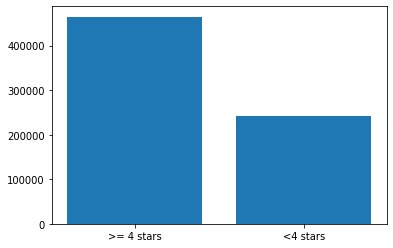

In [12]:
plt.bar(['>= 4 stars', '<4 stars'],[len(positive_full), len(negative_full)])
plt.show()

In [13]:
len(positive_full), len(negative_full)

(464699, 241947)

## Filter dataset with text >= 70 (to ensure that the words contain enough information)

In [14]:
filtered = merged_df[merged_df['text_length']>=70]
positive = filtered[filtered['stars_x']>=4]
negative = filtered[filtered['stars_x']<4]

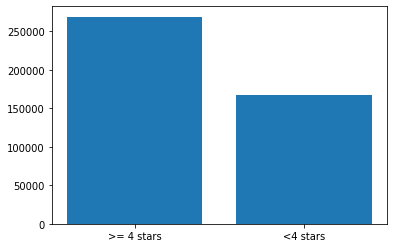

In [15]:
plt.bar(['>= 4 stars', '<4 stars'],[len(positive), len(negative)])
plt.show()

# Undersampling

In [22]:
pos_sample = positive.sample(n=10000, random_state=1)
neg_sample = negative.sample(n=10000, random_state=1)
final_df = pos_sample.copy()
final_df = final_df.append(neg_sample.copy()).sample(frac=1)

# Clean text

In [23]:
# Split into sentences
final_df['review_splitted'] = final_df['text'].apply(sent_tokenize)
final_df

,votes,user_id,review_id,stars_x,date,text,type_x,business_id,label_x,text_length,...,name,neighborhoods,longitude,state,stars_y,latitude,attributes,type_y,label_y,review_splitted
262373,"{'funny': 0, 'useful': 0, 'cool': 0}",ZThq59TH_mO4ObXD5ARR3A,qp3AWUH6IGtUctwnsuIJSg,5,2014-05-02,The teppan table was delish! We started in th...,review,uR2aNW75R4oYs9w7aw-_kQ,1,104,...,Sapporo,[],-111.926314,AZ,3.5,33.616473,"{'Alcohol': 'full_bar', 'Noise Level': 'loud',...",business,0.0,"[The teppan table was delish!, We started in t..."
810400,"{'funny': 0, 'useful': 0, 'cool': 0}",LuoYs_dKwGAzo8egvxb5lA,VMNlNNh0UJVfUd39WUFj6Q,1,2014-03-29,Although I absolutely love the chicken and gre...,review,mZBCQ9l6XKjyHi14mPjZFQ,0,127,...,El Pollo Loco,[Centennial],-115.287486,NV,3.0,36.289611,"{'Take-out': True, 'Wi-Fi': 'free', 'Drive-Thr...",business,0.0,[Although I absolutely love the chicken and gr...
198914,"{'funny': 0, 'useful': 0, 'cool': 0}",eNeGXnmx532KMADrtlh1Zw,-rS3RM0lQgnwWPrmgxr3SQ,1,2014-07-02,This restaurant has been here forever and used...,review,CM4LY-sjD0Q9HivGTFHdoA,0,136,...,Chicago Joes,[Downtown],-115.147884,NV,3.5,36.160997,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,0.0,[This restaurant has been here forever and use...
238263,"{'funny': 0, 'useful': 0, 'cool': 0}",DPRMPB7te_TVqD8sXzFmoA,QFbyWjBaaILJyCanLQk3wQ,3,2009-11-10,"We have a Roy's in Dallas, which I have passed...",review,QySefgRL-TSHDNEd336FtA,0,269,...,Roy's Restaurant,[Westside],-115.285194,NV,4.0,36.158517,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0,"[We have a Roy's in Dallas, which I have passe..."
312302,"{'funny': 0, 'useful': 2, 'cool': 0}",MAmjOsc5NaZwEclbhba5Lg,RoIYW8PDMSGqMNzGYPz_nw,3,2007-12-20,This place is overrated and hyped up too much....,review,CZjcFdvJhksq9dy58NVEzw,0,355,...,The Buffet at Bellagio,[The Strip],-115.176409,NV,3.5,36.113160,"{'Alcohol': 'full_bar', 'Open 24 Hours': False...",business,0.0,[This place is overrated and hyped up too much...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893528,"{'funny': 2, 'useful': 8, 'cool': 11}",glRXVWWD6x1EZKfjJawTOg,h9hRwtsIuu2FzcgDg7fsBw,4,2013-02-04,I came for Dana's Happy Hour UYE. Happy Hour i...,review,qpo6O2Ozbrn8wFnoCM4slA,1,354,...,P.J. Clarke's New York Chophouse,[The Strip],-115.172945,NV,4.0,36.118399,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0,"[I came for Dana's Happy Hour UYE., Happy Hour..."
897990,"{'funny': 0, 'useful': 0, 'cool': 0}",HGZJv5wStNj-Q__SWrrDwQ,V0OV0mcDtJydSHWucTo-Ew,2,2011-11-28,I love tacos and I love trying out different r...,review,wN_wAXWg8W94v04eqijy6g,0,184,...,Tacos Atoyac,[],-112.098292,AZ,4.5,33.538635,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0,[I love tacos and I love trying out different ...
401818,"{'funny': 0, 'useful': 0, 'cool': 0}",9Huz3U3skkZU5GgEf-qR4A,gNHRqHZMfbJRO59T58gCRw,4,2012-02-25,"I planned on staying away from pizza in Vegas,...",review,83DsSlg-swjLzmZnUzq2UA,1,71,...,Settebello Pizzeria Napoletana,[],-115.083839,NV,4.5,36.022104,"{'Take-out': True, 'Wi-Fi': 'free', 'Good For'...",business,1.0,[I planned on staying away from pizza in Vegas...
237286,"{'funny': 0, 'useful': 1, 'cool': 0}",BzmUg1X1cM7u6izXck77-w,FPw_X4Ua9tZ44-DmklBvjw,5,2013-05-10,I thought I had found a real gem until I disco...,review,9XlLE3H3j5Uv0w8V01yomQ,1,137,...,Lakes Lounge,[The Lakes],-115.284254,NV,4.0,36.138420,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': ...",business,1.0,[I thought I had found a real gem until I disc...


In [24]:
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

In [25]:
def process_text(text):
    # remove '\n' present in the raw reviews
    text = text.replace('\n', ' ')
    # lower text
    text = text.lower()
    # split sentence into words
    token = word_tokenize(text)
    # spelling error check
    # token = [checker(x) for x in token]
    # remove punctuation
    table = str.maketrans('', '', string.punctuation)
    stripped = [x.translate(table) for x in token]
    # remove remaining tokens that are not alphabetic
    word = [x for x in stripped if x.isalpha()]
    # filter out stop words
    stop_words = set(stopwords.words('english'))
    stop_words.remove('not')
    word = [x for x in word if not x in stop_words]
    # lemmatization
    lemmatized_output = [lemmatizer.lemmatize(x, get_wordnet_pos(x)) for x in word]
    # join all words into one sentence
    result = " ".join(lemmatized_output)
    return result

In [20]:
tqdm.pandas()

In [26]:
final_df['cleaned'] = final_df['review_splitted'].progress_apply(lambda reviews: [process_text(sentence) for sentence in reviews])
final_df['cleaned']

100%|██████████| 20000/20000 [07:56<00:00, 42.00it/s]


262373    [teppan table delish, start bar happy hourif l...
810400    [although absolutely love chicken great taste ...
198914    [restaurant forever use one favorite spot not ...
238263    [roy dallas pass several occasion, always hear...
312302    [place overrate hyped much, many friend hype m...
                                ...                        
893528    [come dana happy hour uye, happy hour normally...
897990    [love taco love try different restaurant serve...
401818    [plan stay away pizza vega settebello make gla...
237286    [thought found real gem discover friend alread...
340550    [really enjoy experience restaurant, food beau...
Name: cleaned, Length: 20000, dtype: object

In [27]:
joblib.dump(final_df, f'./gdrive/My Drive/BT4222/cleaned_data.pkl')

['./gdrive/My Drive/BT4222/cleaned_data.pkl']

In [28]:
final_df.iloc[-2]['cleaned']

['thought found real gem discover friend already frequent patron lake lounge restaurant',
 'restaurant game bar separate entrance air handle system smoke restaurant area',
 'steak sandwich steal',
 'decent steak good crusty roll accompany either fry coleslaw onion ring',
 'friend swear fish chip state tartar sauce best ever',
 'saw french onion soup last night know wife would love fan soup',
 'service always friendly attentive',
 'restaurant game bar nt see could well']